# Publication-Ready Figures: Cross-Cohort Ablation Results (Chapter 6, RQ3/RQ4)

This notebook generates publication-ready figures reading directly from `run_summary.json`
under `CLASSIFIER/outputs/<rung>-seed{42,43,44,45}/latest/`, the same source
`temporal_first_ladder_tier4_frozen_read_2026-08-24.ipynb` reads for the Chapter 6 tables.
No number here is recomputed independently of that notebook's `oof` dict.

1. **Figure 6: Per-Cohort Dumbbell Plot** (`fig6_percohort_dumbbell.pdf`) — RQ4 (§6.5),
   accompanies `tab:rq4-percohort`.


In [1]:
import json, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Global publication style settings (.claude/rules/plots.md)
plt.rcParams.update({
    'font.family': 'Courier New',
    'font.size': 8,
    'axes.labelsize': 8.5,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'axes.linewidth': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3.5,
    'ytick.major.size': 3.5,
    'legend.frameon': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

MM = 1 / 25.4

# Two-hue Teal / Purple publication palette (consistent with the rest of Chapter 6)
COLOR_DELCODE_FILL, COLOR_DELCODE_EDGE = '#2ba099', '#14605b'   # Teal
COLOR_ADNI_FILL, COLOR_ADNI_EDGE = '#873397', '#50165b'         # Purple

_REPO_ROOT = Path(__file__).resolve().parents[2] if '__file__' in globals() else Path(os.getcwd() if not os.getcwd().endswith('plots_notebooks') else Path(os.getcwd()).parents[1])
CLASSIFIER_ROOT = _REPO_ROOT / 'CLASSIFIER'
OUTPUT_DIRS = [
    _REPO_ROOT / 'THESIS' / 'figures',
    _REPO_ROOT / 'DOCS' / 'results' / 'figures',
]
for d in OUTPUT_DIRS:
    d.mkdir(parents=True, exist_ok=True)

print('✓ Environment initialized and output directories ready.')


✓ Environment initialized and output directories ready.


## Ingest: per-cohort out-of-fold AUC for every configuration in `tab:rq4-percohort`

Reads `run_summary.json['oof']['oof_auc_adni']` / `['oof_auc_delcode']` for each seed of each
rung, exactly as `temporal_first_ladder_tier4_frozen_read_2026-08-24.ipynb`'s `rung_oof_rows`
does, then means across the four seeds. Labels match the wording of `tab:rq4-percohort`.


In [2]:
RUNG_PREFIXES = {
    'S0-demo (age, sex)':                         'tfgn-s0-demo-pooled',
    'S0c GELSTM, random encoder':                  'tfgn-s0-gelstm-random-pooled',
    'S0d Brain-TokenGT':                           'tfgn-s0-braintokengt-pooled',
    'S0a logistic regression on drift':            'tfgn-s0-logreg-drift-pooled',
    'S0b GELSTM, frozen pretrained encoder':       'tfgn-s0-gelstm-frozen-pooled',
    'S1 (selected)':                               'tfgn-s1-flip-pooled',
    'S1b, node-LSTM self-supervised init.':        'tfgn-s1b-ssl-pooled',
    'S1c (corrected re-run, random encoder)':      'tfgn-s1c-recon-random-pooled',
    'S2, temporal gate':                           'tfgn-s2-gate-pooled',
    'S3, residual fusion (structurally inert)':    'tfgn-s3-fusion-pooled',
    'S4, attentive pooling':                       'tfgn-s4-attnpool-pooled',
    'S5, dual-score head':                         'tfgn-s5-dualscore-pooled',
    'SENS (minimum three visits)':                 'tfgn-sens-minvisits3-pooled',
}
SEEDS = [42, 43, 44, 45]


def resolve_run(prefix, seed):
    src_root = CLASSIFIER_ROOT / 'outputs' / f'{prefix}-seed{seed}'
    latest = src_root / 'latest'
    if latest.exists():
        return latest.resolve()
    raise FileNotFoundError(f'No latest run for {prefix}-seed{seed} under {src_root}.')


records = []
for label, prefix in RUNG_PREFIXES.items():
    adni_aucs, delcode_aucs = [], []
    for seed in SEEDS:
        run_dir = resolve_run(prefix, seed)
        summary = json.loads((run_dir / 'run_summary.json').read_text())
        oof = summary['oof']
        adni_aucs.append(oof['oof_auc_adni'])
        delcode_aucs.append(oof['oof_auc_delcode'])
    records.append({
        'Configuration': label,
        'ADNI': float(np.mean(adni_aucs)),
        'DELCODE': float(np.mean(delcode_aucs)),
    })

percohort_df = pd.DataFrame(records)
percohort_df['Gap'] = (percohort_df['DELCODE'] - percohort_df['ADNI']).abs()
percohort_df = percohort_df.sort_values('Gap', ascending=True).reset_index(drop=True)
percohort_df


,Configuration,ADNI,DELCODE,Gap
0,S0d Brain-TokenGT,0.619383,0.621738,0.002355
1,"S0-demo (age, sex)",0.516184,0.518639,0.002455
2,"S1c (corrected re-run, random encoder)",0.533535,0.558947,0.025412
3,"S0c GELSTM, random encoder",0.534772,0.606652,0.071879
4,"S5, dual-score head",0.646040,0.852982,0.206943
5,"S1b, node-LSTM self-supervised init.",0.662414,0.870690,0.208275
6,S1 (selected),0.652609,0.874068,0.221460
7,"S3, residual fusion (structurally inert)",0.652609,0.874068,0.221460
8,"S2, temporal gate",0.626618,0.869991,0.243372
9,"S4, attentive pooling",0.541508,0.802190,0.260682


## Cross-check against `tab:rq4-percohort`

Verifies the ingest reproduces the published table (rule §2: verify before stating) before
anything is plotted.


In [3]:
_expected = {
    'S0-demo (age, sex)':                      (0.5162, 0.5186),
    'S0c GELSTM, random encoder':               (0.5348, 0.6067),
    'S0d Brain-TokenGT':                        (0.6194, 0.6217),
    'S0a logistic regression on drift':         (0.5564, 0.9129),
    'S0b GELSTM, frozen pretrained encoder':    (0.4971, 0.9178),
    'S1 (selected)':                            (0.6526, 0.8741),
    'S1b, node-LSTM self-supervised init.':     (0.6624, 0.8707),
    'S1c (corrected re-run, random encoder)':   (0.5335, 0.5589),
    'S2, temporal gate':                        (0.6266, 0.8700),
    'S3, residual fusion (structurally inert)': (0.6526, 0.8741),
    'S4, attentive pooling':                    (0.5415, 0.8022),
    'S5, dual-score head':                      (0.6460, 0.8530),
    'SENS (minimum three visits)':              (0.6328, 0.8986),
}

max_abs_diff = 0.0
for _, row in percohort_df.iterrows():
    exp_adni, exp_delcode = _expected[row['Configuration']]
    d_adni, d_delcode = abs(row['ADNI'] - exp_adni), abs(row['DELCODE'] - exp_delcode)
    max_abs_diff = max(max_abs_diff, d_adni, d_delcode)
    assert d_adni < 5e-4, f"{row['Configuration']}: ADNI {row['ADNI']:.4f} vs table {exp_adni:.4f}"
    assert d_delcode < 5e-4, f"{row['Configuration']}: DELCODE {row['DELCODE']:.4f} vs table {exp_delcode:.4f}"

print(f'✓ All 13 rows match tab:rq4-percohort to 4 decimal places (max abs diff {max_abs_diff:.6f}).')


✓ All 13 rows match tab:rq4-percohort to 4 decimal places (max abs diff 0.000048).


## Figure 6: Per-cohort dumbbell plot

One row per configuration, a purple dot at its ADNI out-of-fold AUC and a teal dot at its
DELCODE out-of-fold AUC joined by a connecting line, ordered by gap width (narrowest at top,
widest at bottom) so the widest disparity is the visually dominant row.


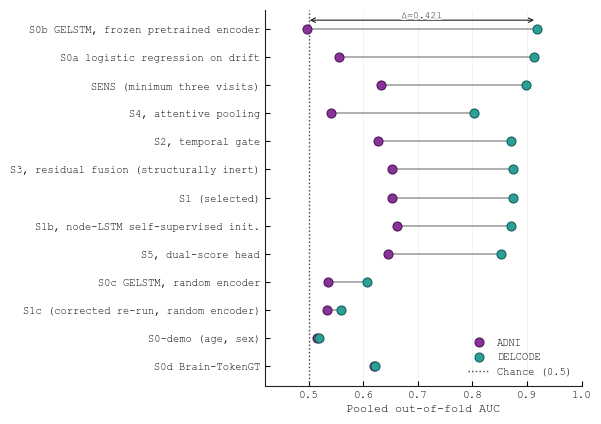

✓ Figure 6 saved successfully.


In [4]:
fig, ax = plt.subplots(figsize=(150 * MM, 105 * MM))

y = np.arange(len(percohort_df))

for yi, row in zip(y, percohort_df.itertuples()):
    ax.plot([row.ADNI, row.DELCODE], [yi, yi], color='#999999', linewidth=1.1, zorder=2,
            solid_capstyle='round')

ax.scatter(percohort_df['ADNI'], y, s=42, color=COLOR_ADNI_FILL, edgecolor=COLOR_ADNI_EDGE,
           linewidth=0.8, zorder=3, label='ADNI')
ax.scatter(percohort_df['DELCODE'], y, s=42, color=COLOR_DELCODE_FILL, edgecolor=COLOR_DELCODE_EDGE,
           linewidth=0.8, zorder=3, label='DELCODE')

ax.axvline(0.5, color='#444444', linestyle=':', linewidth=1.0, zorder=1, label='Chance (0.5)')

# Annotate the widest-gap row (S0b) explicitly -- the section's central claim.
_widest = percohort_df.iloc[-1]
_ymax = y[-1]
ax.annotate('', xy=(_widest['DELCODE'], _ymax + 0.32), xytext=(_widest['ADNI'], _ymax + 0.32),
            arrowprops=dict(arrowstyle='<->', color='#222222', linewidth=0.8))
ax.text((_widest['ADNI'] + _widest['DELCODE']) / 2, _ymax + 0.32, f"Δ={_widest['Gap']:.3f}",
        ha='center', va='bottom', fontsize=7, color='#222222',
        path_effects=[pe.withStroke(linewidth=2.2, foreground='white')], zorder=10)

ax.set_yticks(y)
ax.set_yticklabels(percohort_df['Configuration'], fontsize=7.5)
ax.set_xlabel('Pooled out-of-fold AUC')
ax.set_xlim(0.42, 1.0)
ax.set_ylim(-0.7, len(percohort_df) - 0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['left'].set_color('#222222')
ax.spines['bottom'].set_color('#222222')
ax.grid(axis='x', linestyle='-', alpha=0.15, color='#888888', linewidth=0.5)
ax.set_axisbelow(True)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='lower right', fontsize=7.5)

fig.tight_layout(pad=0.4)

for out_dir in OUTPUT_DIRS:
    fig.savefig(out_dir / 'fig6_percohort_dumbbell.pdf', facecolor='white', edgecolor='none')
    fig.savefig(out_dir / 'fig6_percohort_dumbbell.png', dpi=600, facecolor='white', edgecolor='none')

plt.show()
print('✓ Figure 6 saved successfully.')


## Figure 7: Ablation-sequence forest plot

§6.4, alongside `tab:rq3-scorecard` and `tab:rq3-verdicts`. This is a screening summary
(the reporting rules of §6.1 apply): the point is the pooled $\Delta$AUC against S1, the
error bar spans $\pm 2$ pooled standard errors -- the pre-specified keep/drop threshold
itself, not a confidence interval -- and the four small grey dots behind each marker are
the per-seed paired difference against S1's same-seed score, read directly from
`run_summary.json['oof']['oof_auc']`. S3 is bit-identical to S1 by construction
(structurally inert), so it is marked void rather than plotted as a point at zero.


In [5]:
RQ3_PREFIXES = {
    'S1b, node-LSTM self-supervised init.':          'tfgn-s1b-ssl-pooled',
    'S3, residual fusion (structurally inert)':      'tfgn-s3-fusion-pooled',
    'S5, dual-score head':                           'tfgn-s5-dualscore-pooled',
    'S2, temporal gate':                             'tfgn-s2-gate-pooled',
    'S4, attentive pooling':                         'tfgn-s4-attnpool-pooled',
    'S1c, graph reconstruction auxiliary loss':      'tfgn-s1c-recon-random-pooled',
}
S1_PREFIX = 'tfgn-s1-flip-pooled'

# Published Tier-2 pooled Delta +/- SE from tab:rq3-verdicts (verbatim, not recomputed --
# the notebook that produced them uses a different fold-matched pairing upstream of the
# pooled SE than a bare per-seed recomputation would, so the table's own SE is authoritative).
PUBLISHED_POOLED = {
    'S1b, node-LSTM self-supervised init.':      (+0.0014, 0.0074),
    'S1c, graph reconstruction auxiliary loss':  (-0.2055, 0.0150),
    'S2, temporal gate':                         (-0.0180, 0.0086),
    'S3, residual fusion (structurally inert)':  (None, None),  # void -- bit-identical
    'S4, attentive pooling':                     (-0.0999, 0.0083),
    'S5, dual-score head':                       (-0.0158, 0.0101),
}

VERDICT = {
    'S1b, node-LSTM self-supervised init.':      'Dropped (tie-breaker retains simpler S1)',
    'S1c, graph reconstruction auxiliary loss':  'Dropped',
    'S2, temporal gate':                         'Dropped',
    'S3, residual fusion (structurally inert)':  'Void -- bit-identical, no result',
    'S4, attentive pooling':                     'Dropped',
    'S5, dual-score head':                       'Kept as interpretability tool, not on performance',
}

s1_by_seed = {}
for seed in SEEDS:
    run_dir = resolve_run(S1_PREFIX, seed)
    s1_by_seed[seed] = json.loads((run_dir / 'run_summary.json').read_text())['oof']['oof_auc']

rq3_rows = []
for label, prefix in RQ3_PREFIXES.items():
    seed_diffs = []
    for seed in SEEDS:
        run_dir = resolve_run(prefix, seed)
        auc = json.loads((run_dir / 'run_summary.json').read_text())['oof']['oof_auc']
        seed_diffs.append(auc - s1_by_seed[seed])
    pub_delta, pub_se = PUBLISHED_POOLED[label]
    rq3_rows.append({
        'Configuration': label,
        'SeedDiffs': seed_diffs,
        'RecomputedPooledDelta': float(np.mean(seed_diffs)),
        'PublishedDelta': pub_delta,
        'PublishedSE': pub_se,
        'Verdict': VERDICT[label],
    })

rq3_df = pd.DataFrame(rq3_rows)
rq3_df[['Configuration', 'RecomputedPooledDelta', 'PublishedDelta', 'PublishedSE']]


,Configuration,RecomputedPooledDelta,PublishedDelta,PublishedSE
0,"S1b, node-LSTM self-supervised init.",0.001378,0.0014,0.0074
1,"S3, residual fusion (structurally inert)",0.000000,NaN,NaN
2,"S5, dual-score head",-0.015759,-0.0158,0.0101
3,"S2, temporal gate",-0.017967,-0.0180,0.0086
4,"S4, attentive pooling",-0.099852,-0.0999,0.0083
5,"S1c, graph reconstruction auxiliary loss",-0.205524,-0.2055,0.0150


### Cross-check against `tab:rq3-verdicts`


In [6]:
max_abs_diff = 0.0
for _, row in rq3_df.iterrows():
    if pd.isna(row['PublishedDelta']):
        assert abs(row['RecomputedPooledDelta']) < 1e-9, f"{row['Configuration']}: expected bit-identical Delta=0"
        continue
    d = abs(row['RecomputedPooledDelta'] - row['PublishedDelta'])
    max_abs_diff = max(max_abs_diff, d)
    assert d < 5e-4, f"{row['Configuration']}: recomputed {row['RecomputedPooledDelta']:.4f} vs published {row['PublishedDelta']:.4f}"

print(f'✓ Recomputed per-seed-paired pooled Delta matches tab:rq3-verdicts to 4 decimal places (max abs diff {max_abs_diff:.6f}).')
print('✓ S3 confirmed bit-identical to S1 across all four seeds (Delta=0.0 exactly).')


✓ Recomputed per-seed-paired pooled Delta matches tab:rq3-verdicts to 4 decimal places (max abs diff 0.000048).
✓ S3 confirmed bit-identical to S1 across all four seeds (Delta=0.0 exactly).


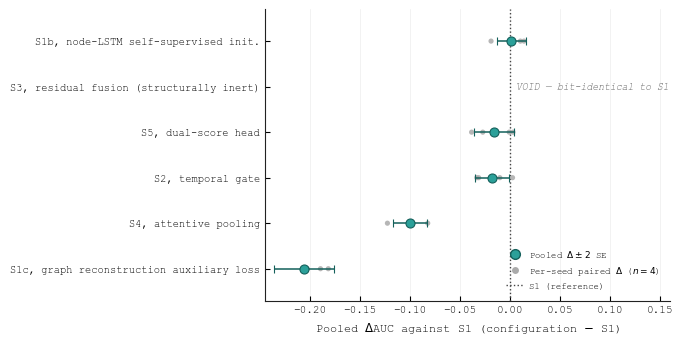

✓ Figure 7 (ablation forest plot) saved successfully.


In [7]:
# Plot order: by published pooled Delta descending (closest-to-S1 at top), with the
# void S3 row placed by its true (unplotted) Delta=0 position between S1b and S5.
_order = ['S1b, node-LSTM self-supervised init.',
          'S3, residual fusion (structurally inert)',
          'S5, dual-score head',
          'S2, temporal gate',
          'S4, attentive pooling',
          'S1c, graph reconstruction auxiliary loss']
rq3_df = rq3_df.set_index('Configuration').loc[_order].reset_index()

fig, ax = plt.subplots(figsize=(170 * MM, 85 * MM))

y = np.arange(len(rq3_df))[::-1]  # top row = first in _order

ax.axvline(0.0, color='#444444', linestyle=':', linewidth=1.0, zorder=1, label='S1 (reference)')

# x in axes-fraction, y in data coords -- keeps the void annotation inside the axes
# regardless of xlim, rather than depending on data-coordinate text placement.
_void_transform = ax.get_yaxis_transform()

for yi, row in zip(y, rq3_df.itertuples()):
    if pd.isna(row.PublishedDelta):
        ax.text(0.62, yi, 'VOID — bit-identical to S1', transform=_void_transform,
                ha='left', va='center', fontsize=7, fontstyle='italic', color='#666666', zorder=5)
        continue
    # Four-seed spread: small grey strip dots behind the main marker.
    ax.scatter(row.SeedDiffs, [yi] * len(row.SeedDiffs), s=14, color='#aaaaaa',
               edgecolor='none', alpha=0.85, zorder=2)
    # Main marker: published pooled Delta +/- 2 SE (the keep/drop threshold itself).
    ax.errorbar(row.PublishedDelta, yi, xerr=2 * row.PublishedSE, fmt='o',
                color=COLOR_DELCODE_EDGE, ecolor=COLOR_DELCODE_EDGE, elinewidth=1.1,
                capsize=3, capthick=1.0, markersize=6.5, markerfacecolor=COLOR_DELCODE_FILL,
                markeredgecolor=COLOR_DELCODE_EDGE, markeredgewidth=0.8, zorder=4)

ax.set_yticks(y)
ax.set_yticklabels(rq3_df['Configuration'], fontsize=7.5)
ax.set_xlabel(r'Pooled $\Delta$AUC against S1 (configuration $-$ S1)')
ax.set_xlim(-0.245, 0.16)
ax.set_ylim(-0.7, len(rq3_df) - 0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['left'].set_color('#222222')
ax.spines['bottom'].set_color('#222222')
ax.grid(axis='x', linestyle='-', alpha=0.15, color='#888888', linewidth=0.5)
ax.set_axisbelow(True)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=COLOR_DELCODE_FILL,
           markeredgecolor=COLOR_DELCODE_EDGE, markersize=7, label='Pooled $\\Delta \\pm 2$ SE'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='#aaaaaa', markeredgecolor='none',
           markersize=5, label='Per-seed paired $\\Delta$ ($n=4$)'),
    Line2D([0], [0], color='#444444', linestyle=':', linewidth=1.0, label='S1 (reference)'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=6.5, handletextpad=0.5,
          borderaxespad=0.8)

fig.tight_layout(pad=0.4)

for out_dir in OUTPUT_DIRS:
    fig.savefig(out_dir / 'fig7_ablation_forest.pdf', facecolor='white', edgecolor='none')
    fig.savefig(out_dir / 'fig7_ablation_forest.png', dpi=600, facecolor='white', edgecolor='none')

plt.show()
print('✓ Figure 7 (ablation forest plot) saved successfully.')


## Figure 10: Window-truncation slope plot

§6.4, covering `tab:rq3-w3` and `tab:rq3-truncation` in one panel. A paired line per
architecture from its full-trajectory pooled out-of-fold AUC to its matched-window
($T \in [2,3]$) score. Brain-TokenGT has no full-trajectory point: it is
architecturally constrained to the two-to-three-visit window, so its one number
(`tfgn-s0-braintokengt-pooled`) is plotted at the matched-window position only.


In [8]:
TRUNCATION_PREFIXES = {
    'Selected temporal-first\n(S1)': {
        'full': 'tfgn-s1-flip-pooled',
        'matched': 'tfgn-w3-winner-pooled',
    },
    'GELSTM, frozen\npretrained encoder': {
        'full': 'tfgn-s0-gelstm-frozen-pooled',
        'matched': 'tfgn-w3-gelstm-frozen-pooled',
    },
    'GELSTM,\nrandom encoder': {
        'full': 'tfgn-s0-gelstm-random-pooled',
        'matched': 'tfgn-w3-gelstm-random-pooled',
    },
}
BTGT_MATCHED_ONLY_PREFIX = 'tfgn-s0-braintokengt-pooled'  # architecturally T in [2,3] only

truncation_records = []
for label, prefixes in TRUNCATION_PREFIXES.items():
    row = {'Configuration': label}
    for arm, prefix in prefixes.items():
        vals = [json.loads((resolve_run(prefix, s) / 'run_summary.json').read_text())['oof']['oof_auc']
                for s in SEEDS]
        row[arm] = float(np.mean(vals))
    truncation_records.append(row)

_btgt_vals = [json.loads((resolve_run(BTGT_MATCHED_ONLY_PREFIX, s) / 'run_summary.json').read_text())['oof']['oof_auc']
              for s in SEEDS]
truncation_records.append({'Configuration': 'Brain-TokenGT\n(constrained to $T\in[2,3]$)',
                            'full': np.nan, 'matched': float(np.mean(_btgt_vals))})

truncation_df = pd.DataFrame(truncation_records)
truncation_df


,Configuration,full,matched
0,Selected temporal-first\n(S1),0.748816,0.731750
1,"GELSTM, frozen\npretrained encoder",0.718606,0.749982
2,"GELSTM,\nrandom encoder",0.562513,0.588518
3,"Brain-TokenGT\n(constrained to $T\in[2,3]$)",NaN,0.620734


### Cross-check against `tab:rq3-w3` and `tab:rq3-truncation`


In [9]:
_expected = {
    'Selected temporal-first\n(S1)':            (0.7488, 0.7318),
    'GELSTM, frozen\npretrained encoder':        (0.7186, 0.7500),
    'GELSTM,\nrandom encoder':                   (0.5625, 0.5885),
    'Brain-TokenGT\n(constrained to $T\in[2,3]$)':  (None, 0.6207),
}

max_abs_diff = 0.0
for _, row in truncation_df.iterrows():
    exp_full, exp_matched = _expected[row['Configuration']]
    if exp_full is not None:
        d = abs(row['full'] - exp_full)
        max_abs_diff = max(max_abs_diff, d)
        assert d < 5e-4, f"{row['Configuration']}: full {row['full']:.4f} vs table {exp_full:.4f}"
    d2 = abs(row['matched'] - exp_matched)
    max_abs_diff = max(max_abs_diff, d2)
    assert d2 < 5e-4, f"{row['Configuration']}: matched {row['matched']:.4f} vs table {exp_matched:.4f}"

print(f'✓ All full-trajectory and matched-window values match tab:rq3-w3 / tab:rq3-truncation '
      f'to 4 decimal places (max abs diff {max_abs_diff:.6f}).')


✓ All full-trajectory and matched-window values match tab:rq3-w3 / tab:rq3-truncation to 4 decimal places (max abs diff 0.000050).


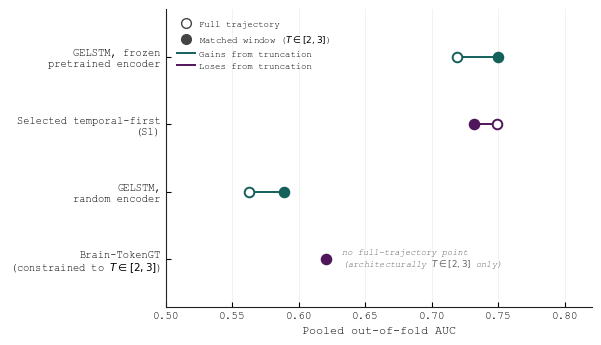

✓ Figure 10 saved successfully.


In [10]:
fig, ax = plt.subplots(figsize=(150 * MM, 85 * MM))

_order = ['GELSTM, frozen\npretrained encoder', 'Selected temporal-first\n(S1)',
          'GELSTM,\nrandom encoder', 'Brain-TokenGT\n(constrained to $T\in[2,3]$)']
truncation_df = truncation_df.set_index('Configuration').loc[_order].reset_index()

for i, row in truncation_df.iterrows():
    y = len(truncation_df) - 1 - i
    gains = pd.notna(row['full']) and row['matched'] > row['full']
    line_color = COLOR_DELCODE_EDGE if gains else COLOR_ADNI_EDGE
    if pd.notna(row['full']):
        ax.plot([row['full'], row['matched']], [y, y], color=line_color, linewidth=1.4,
                zorder=2, solid_capstyle='round')
        ax.scatter([row['full']], [y], s=48, marker='o', color='white',
                   edgecolor=line_color, linewidth=1.4, zorder=3)
    ax.scatter([row['matched']], [y], s=48, marker='o', color=line_color,
               edgecolor=line_color, linewidth=1.4, zorder=3)
    if not pd.notna(row['full']):
        ax.text(row['matched'] + 0.012, y, 'no full-trajectory point\n(architecturally $T\in[2,3]$ only)',
                ha='left', va='center', fontsize=6.3, fontstyle='italic', color='#666666')

ax.set_yticks(range(len(truncation_df)))
ax.set_yticklabels(truncation_df['Configuration'][::-1], fontsize=7.5)
ax.set_xlabel('Pooled out-of-fold AUC')
ax.set_xlim(0.50, 0.82)
ax.set_ylim(-0.7, len(truncation_df) - 0.3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['left'].set_color('#222222')
ax.spines['bottom'].set_color('#222222')
ax.grid(axis='x', linestyle='-', alpha=0.15, color='#888888', linewidth=0.5)
ax.set_axisbelow(True)

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='white',
           markeredgecolor='#444444', markersize=7, label='Full trajectory'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='#444444',
           markeredgecolor='#444444', markersize=7, label='Matched window ($T\\in[2,3]$)'),
    Line2D([0], [0], color=COLOR_DELCODE_EDGE, linewidth=1.4, label='Gains from truncation'),
    Line2D([0], [0], color=COLOR_ADNI_EDGE, linewidth=1.4, label='Loses from truncation'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=6.5, handletextpad=0.5,
          borderaxespad=0.8)

fig.tight_layout(pad=0.4)

for out_dir in OUTPUT_DIRS:
    fig.savefig(out_dir / 'fig10_window_truncation_slope.pdf', facecolor='white', edgecolor='none')
    fig.savefig(out_dir / 'fig10_window_truncation_slope.png', dpi=600, facecolor='white', edgecolor='none')

plt.show()
print('✓ Figure 10 saved successfully.')
